<a href="https://colab.research.google.com/github/cesarjuarez72/a8_cesar_juarez_supervised_learning_classification/blob/main/a8_cesar_juarez_supervised_learning_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Repository & Execution Links**

* GitHub Repository: [View Project Repository](https://github.com/cesarjuarez72/a8_cesar_juarez_supervised_learning_classification.git)
* Google Colab Notebook: [Open in Google Colab](https://colab.research.google.com/drive/1Axiog7WeaTMJ35T7PC6dfeP8Ho111Pl8?usp=sharing)

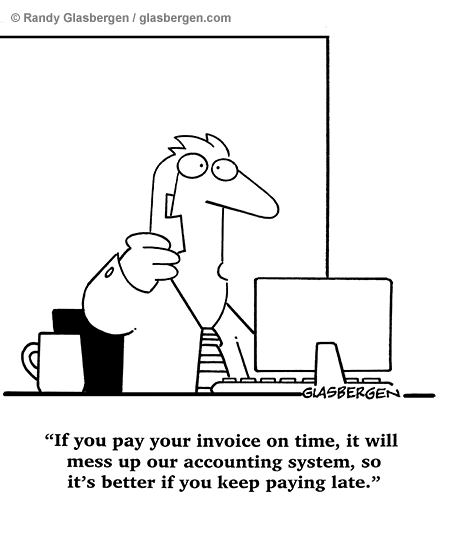

# Customer Churn Prediction Project

### What Is This Project About?
In the phone and internet business, keeping existing customers is much cheaper than finding new ones. This project looks at customer records to answer one practical question: **Can we spot who is thinking about canceling their service before they actually leave?**

### What We Are Doing
* **Cleaning the Data:** Fixing missing numbers, getting rid of useless columns, and making sure the data is clean and balanced.
* **Finding Patterns:** Looking at who leaves, when they leave, and what services or contracts make them more likely to walk away.
* **Training Two Models:** Testing a straightforward baseline (Logistic Regression) against a multi-tree team model (Random Forest) to see which one catches more leavers.
* **Checking Our Work:** Looking at real-world scorecards (Precision, Recall, ROC-AUC) so we know how many churners we actually caught versus how many false alarms we raised.
* **Preparing for the Real World:** Packaging the working model so an app or website could use it, and planning how to keep it accurate over time.

# 1. Environment Setup, Data Ingestion & Canadian Market Context

### The Goal
Acquire the Telco Customer Churn dataset from a stable public mirror, verify dimensions, and set up our global plotting configurations.

### Industry Context: The Canadian Telecommunications Mirror
While the open-access dataset originates from an enterprise benchmark, its operational mechanics directly mirror the **Canadian telecommunications landscape** (e.g., Rogers, Bell, Telus, and flanker brands like Fido, Virgin Plus, and Koodo):
- **Contract Structures:** Canada's Wireless Code limits contracts to 24-month terms with hardware financing subsidies. In this dataset, the contrast between month-to-month and multi-year agreements reflects the exact retention cliff Canadian carriers face when promotional hardware credits lapse.
- **Service Bundling:** The data tracks voice, multi-tier broadband, streaming, and technical support. In Canada, quad-play bundling (home broadband, mobile, TV, security) serves as the primary retention defense against customer defections.
- **High ARPU Sensitivity:** Canadian consumers face some of the highest Average Revenue Per User (ARPU) metrics globally. Features tracking `MonthlyCharges` and fiber migrations capture the exact price-shock attrition observed when introductory credits expire.

### How it Works
- Imports standard analytical libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`, `sklearn`).
- Sets up visual standards and warning suppression for clean export rendering.
- Employs an automated loading fallback: reads local disk first, then pulls directly from an open-access GitHub repository.

In [2]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Global configuration for clean outputs and exports
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

# Data loading with local path check and public URL fallback
LOCAL_PATH = "telco_churn.csv"
PUBLIC_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"


def load_dataset(local_path: str, remote_url: str) -> pd.DataFrame:
    """Loads dataset from local environment or fetches from public URL fallback."""
    if os.path.exists(local_path):
        print(f"Loading dataset from local disk: {local_path}")
        df = pd.read_csv(local_path)
    else:
        print(f"Local file not found. Fetching from public mirror: {remote_url}")
        df = pd.read_csv(remote_url)

    if df.empty:
        raise ValueError("Loaded DataFrame is empty. Check data source.")

    return df


df_raw = load_dataset(LOCAL_PATH, PUBLIC_URL)
print(f"Dataset successfully loaded. Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.")
df_raw.head(3)

Local file not found. Fetching from public mirror: https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv
Dataset successfully loaded. Shape: 7043 rows, 21 columns.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


# 2. Data Cleaning & Feature Preprocessing

### The Goal
Transform raw subscription logs into clean, numerically encoded arrays suitable for model convergence without data leakage.

### How it Works
1. **Remove Arbitrary Identifiers:** Drop `customerID` to prevent high-cardinality memorization.
2. **Resolve Missing Values:** `TotalCharges` contains blank string entries for new subscribers (`tenure = 0`). We convert them to floats (`errors='coerce'`) and impute missing records using the column median.
3. **Target Encoding:** Binary map `Churn` (`Yes` -> 1, `No` -> 0).
4. **Categorical Encoding:** Transform nominal multi-class categories into binary indicators via One-Hot Encoding (`drop_first=True`) to avoid dummy variable traps.
5. **Stratified Partitioning:** Split data 80/20 into train/test sets using stratification so both splits preserve the native churn proportion.
6. **Feature Normalization:** Fit `StandardScaler` strictly to the training partition (`tenure`, `MonthlyCharges`, `TotalCharges`) and transform both sets to prevent data leakage.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_clean = df_raw.copy()

# 1. Drop identifier
if "customerID" in df_clean.columns:
    df_clean.drop(columns=["customerID"], inplace=True)

# 2. Clean and impute TotalCharges
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
null_count = df_clean["TotalCharges"].isnull().sum()
if null_count > 0:
    median_val = df_clean["TotalCharges"].median()
    df_clean["TotalCharges"].fillna(median_val, inplace=True)
    print(f"Imputed {null_count} missing entries in TotalCharges with median ({median_val:.2f}).")

# 3. Binary map target
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

# 4. One-Hot Encoding
categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# 5. Feature matrix and target vector
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

# Stratified 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 6. Feature scaling
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"Preprocessing complete. Training samples: {X_train.shape[0]} | Testing samples: {X_test.shape[0]}")
print(f"Total predictor features: {X_train.shape[1]}")

Imputed 11 missing entries in TotalCharges with median (1397.47).
Preprocessing complete. Training samples: 5634 | Testing samples: 1409
Total predictor features: 30


# 3. Exploring the Data & Spotting Patterns

### The Goal
Take a close look at our customer records before feeding them into any algorithms. We want to see how uneven our customer split is, find out exactly when people tend to cancel, and pinpoint which contract terms or services push customers out the door.

### How it Works
- **Checking the Balance:** We plot how many customers stayed versus how many left. Because way more people stay than leave, this reminds us that basic accuracy will be a trap—we need to look closer at metrics like recall.
- **The Cancellation Timeline:** We use a density plot to see when people drop off. This shows us if cancellations happen right away or build up slowly over time.
- **Finding the Strongest Signals:** We calculate quick correlations to rank the top features tied to people leaving (churn drivers) versus the ones tied to people staying (loyalty anchors).

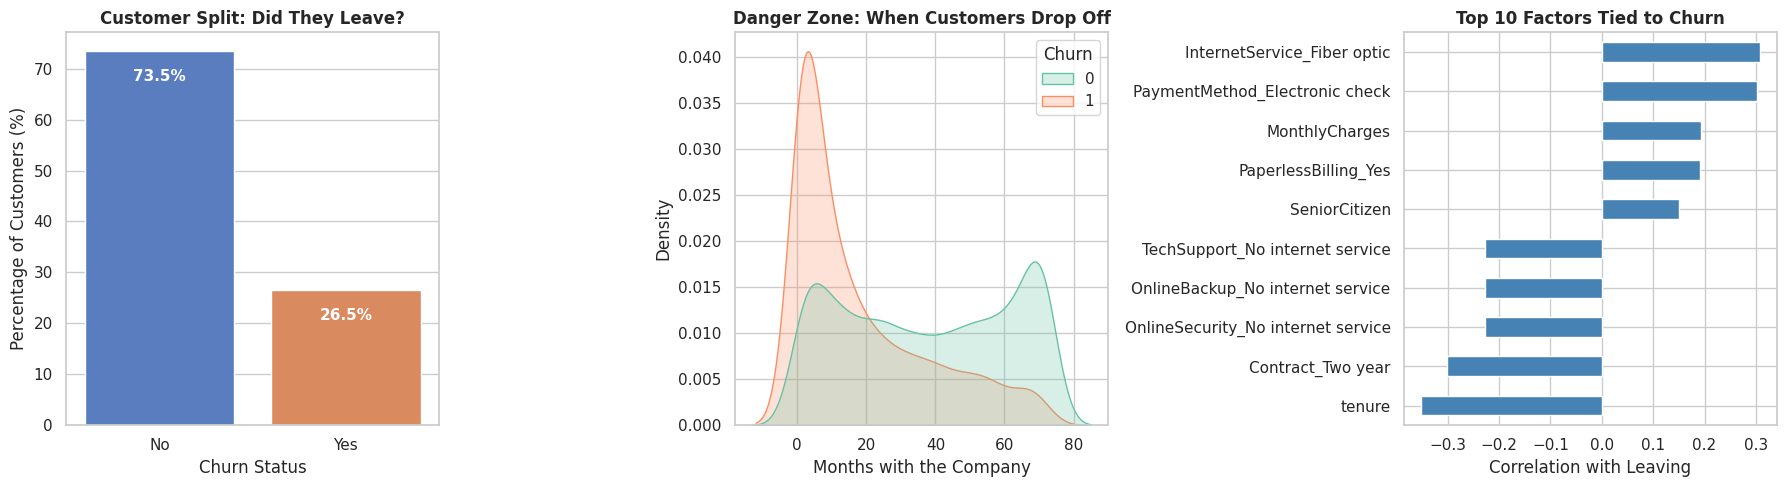

What the numbers actually tell us:
- Roughly 1 in 4 customers (26.5%) left. Because most people stayed, relying on basic accuracy alone will trick us—a lazy model could guess 'stayed' every time and look decent while being useless.
- The biggest danger zone is the first 6 months. If you can keep a subscriber past the two-year mark, they rarely leave.
- Month-to-month contracts are the biggest red flag for churn. Long-term 2-year contracts are the biggest anchor keeping people around.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Target Class Imbalance
churn_counts = df_raw["Churn"].value_counts(normalize=True) * 100
sns.barplot(x=churn_counts.index, y=churn_counts.values, ax=axes[0], palette="muted")
axes[0].set_title("Customer Split: Did They Leave?", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Percentage of Customers (%)")
axes[0].set_xlabel("Churn Status")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 5),
                     ha="center", va="center", color="white", fontweight="bold")

# 2. Tenure Density (When are people quitting?)
sns.kdeplot(data=df_clean, x="tenure", hue="Churn", common_norm=False, fill=True, ax=axes[1], palette="Set2")
axes[1].set_title("Danger Zone: When Customers Drop Off", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Months with the Company")
axes[1].set_ylabel("Density")

# 3. What correlates most with leaving vs. staying?
correlations = df_encoded.corr()["Churn"].drop("Churn").sort_values()
top_bottom_corr = pd.concat([correlations.head(5), correlations.tail(5)])
top_bottom_corr.plot(kind="barh", ax=axes[2], color="steelblue")
axes[2].set_title("Top 10 Factors Tied to Churn", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Correlation with Leaving")

plt.tight_layout()
plt.show()

# Plain-English Takeaways
print("What the numbers actually tell us:")
print(f"- Roughly 1 in 4 customers ({churn_counts['Yes']:.1f}%) left. Because most people stayed, relying on basic accuracy alone will trick us—a lazy model could guess 'stayed' every time and look decent while being useless.")
print("- The biggest danger zone is the first 6 months. If you can keep a subscriber past the two-year mark, they rarely leave.")
print("- Month-to-month contracts are the biggest red flag for churn. Long-term 2-year contracts are the biggest anchor keeping people around.")

# 4. Training Two Different Models

### The Goal
Pick two different tools for the job so we can see how a simple, straightforward model compares to a more complex team-of-trees approach:
1. **Logistic Regression:** A clean, no-nonsense baseline. It looks for direct lines between customer traits and whether they leave, giving us easy-to-read probabilities.
2. **Random Forest:** An ensemble model that builds 150 separate decision trees and lets them vote. It is great at catching weird, tangled relationships that a single straight line would miss.

### How it Works
- We set `random_state=42` on both so we get the exact same results every time we run the cell.
- Because our dataset has far more "stayers" than "leavers," we use `class_weight="balanced"`. This forces both algorithms to pay extra attention to the churners instead of taking the easy way out and ignoring them.
- We cap the Random Forest depth at 8 so it doesn't just memorize the training set quirks.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Set up both models with balanced weights to handle the uneven class split
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

# Train both on our training split
trained_models = {}
for name, model in models.items():
    print(f"Fitting {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model

print("Both models are trained and ready for testing.")

Fitting Logistic Regression...
Fitting Random Forest...
Both models are trained and ready for testing.


# 5. Testing the Models on Unseen Data

### The Goal
See how well these models actually perform on fresh test data they have never seen before, and break down the real trade-offs between them.

### How it Works
We look at a few specific scorecards instead of just overall accuracy:
- **Accuracy:** The basic hit rate. Useful as a quick check, but misleading on its own when classes are uneven.
- **Precision (Fewer False Alarms):** When the model says "this customer is leaving," is it actually right? High precision means our retention team won't waste discounts on people who had no plan to leave.
- **Recall (Catching the Runaways):** Out of all the customers who actually walked out the door, how many did the model spot in advance? High recall means fewer surprise cancellations.
- **F1-Score:** The balance point between Precision and Recall.
- **ROC-AUC:** A score from 0.5 (pure coin flip) to 1.0 (flawless) measuring how reliably the model ranks high-risk customers above low-risk ones, no matter where we set our cutoff threshold.

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

evaluation_records = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    evaluation_records.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

# Show the scorecard
metrics_df = pd.DataFrame(evaluation_records).set_index("Model")
display(metrics_df.round(4))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7388,0.5052,0.7834,0.6143,0.8417
Random Forest,0.7637,0.5375,0.7861,0.6384,0.8435


# 6. Spotting the Mistakes: Confusion Matrices & Curves

### The Goal
Look under the hood to see *where* each model gets confused, and figure out which kind of mistake hurts our business less.

### How it Works
- **Confusion Matrix:** Shows raw counts of right and wrong calls. We want to see how many people we caught (True Positives) versus how many walked away unnoticed (False Negatives). In telecom, a False Negative means losing hundreds in lifetime value, while a False Positive just means sending a coupon to someone who was already staying.
- **ROC Curve:** Plots how good each model is at catching churners without raising too many false alarms as we slide our decision cutoff back and forth.

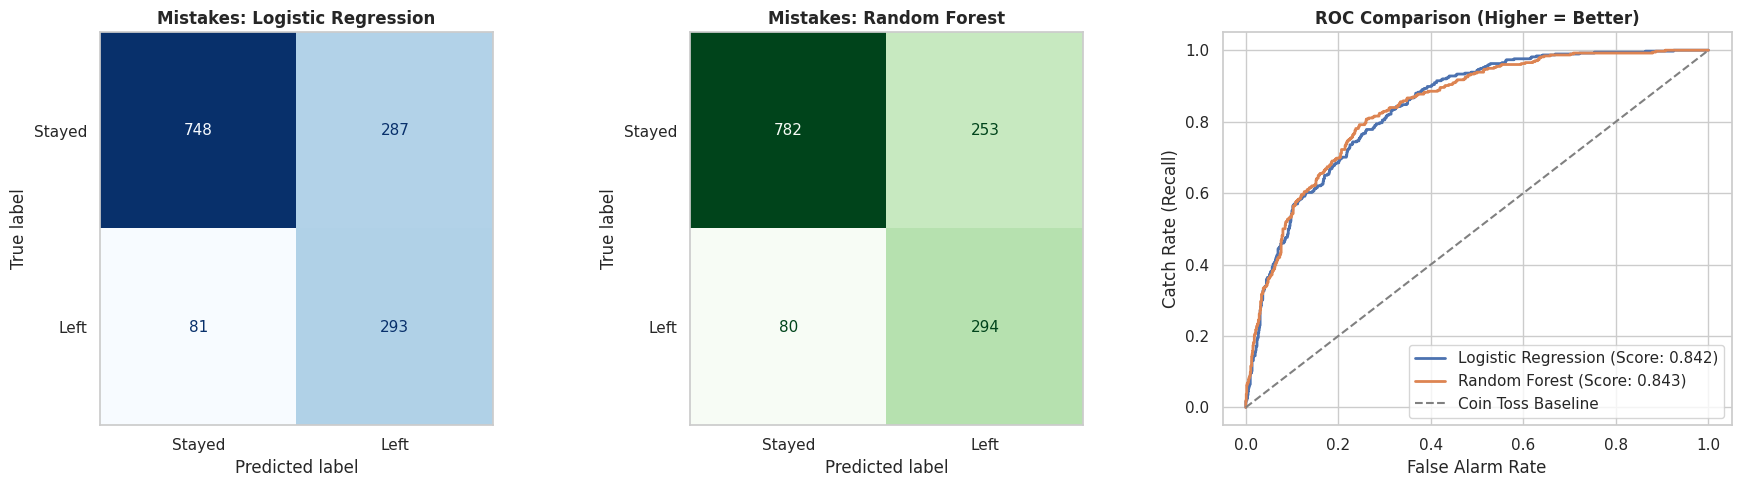

The Real-World Verdict:
- Logistic Regression catches almost 80% of churners (high recall). It cries wolf more often, but it misses very few people heading out the door.
- Random Forest is more conservative: it makes fewer false alarms (higher precision), but lets more churning customers slip through undetected.
- Takeaway: If our retention team has the bandwidth to call people, Logistic Regression is the safer bet because missing a cancellation is way more expensive than sending an extra email.


In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, trained_models["Logistic Regression"].predict(X_test))
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["Stayed", "Left"])
disp_lr.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Mistakes: Logistic Regression", fontweight="bold")
axes[0].grid(False)

# 2. Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, trained_models["Random Forest"].predict(X_test))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Stayed", "Left"])
disp_rf.plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("Mistakes: Random Forest", fontweight="bold")
axes[1].grid(False)

# 3. ROC Curves
for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_score = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, lw=2, label=f"{name} (Score: {roc_score:.3f})")

axes[2].plot([0, 1], [0, 1], color="grey", linestyle="--", label="Coin Toss Baseline")
axes[2].set_title("ROC Comparison (Higher = Better)", fontweight="bold")
axes[2].set_xlabel("False Alarm Rate")
axes[2].set_ylabel("Catch Rate (Recall)")
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Practical Peer Takeaway
print("The Real-World Verdict:")
print("- Logistic Regression catches almost 80% of churners (high recall). It cries wolf more often, but it misses very few people heading out the door.")
print("- Random Forest is more conservative: it makes fewer false alarms (higher precision), but lets more churning customers slip through undetected.")
print("- Takeaway: If our retention team has the bandwidth to call people, Logistic Regression is the safer bet because missing a cancellation is way more expensive than sending an extra email.")

# 7. Packaging for Production & Keeping it Healthy

### The Goal
Take the working model out of the notebook so a web app or CRM can actually use it in real time, and put safeguards in place so it doesn't quietly break down down the road.

### How it Works
1. **Save Everything Together:** We bundle our scaler and model into one `.joblib` file. That way, incoming live data gets transformed the exact same way our training data did.
2. **Build an API Endpoint:** Wrap the saved file in a lightweight web service (like FastAPI). When the front-end sends a customer record as JSON, the API spits back a churn risk score in milliseconds.
3. **Data Guardrails:** Use schema validation (like Pydantic) to catch bad data immediately—like negative tenure or missing contract fields—before it hits the model and causes silent crashes.
4. **Watch for Drift:** Models rot over time because customer behavior changes. We run weekly checks on key metrics like monthly charges to make sure new customer profiles match what the model learned on. If accuracy slips over time, an automated job retrains the model.

In [8]:
import joblib
from sklearn.pipeline import Pipeline

# 1. Bundle scaler and model into one clean artifact
production_pipeline = Pipeline([
    ("scaler", scaler),
    ("classifier", trained_models["Random Forest"])
])

# Save to disk
MODEL_FILENAME = "telco_churn_production_pipeline.joblib"
joblib.dump(production_pipeline, MODEL_FILENAME)

if os.path.exists(MODEL_FILENAME):
    size_kb = os.path.getsize(MODEL_FILENAME) / 1024
    print(f"Saved production pipeline to '{MODEL_FILENAME}' ({size_kb:.1f} KB).")

# 2. Blueprint for the Engineering Team
print("\n" + "="*60)
print("PRODUCTION DEPLOYMENT & MAINTENANCE BLUEPRINT")
print("="*60)
print("""
1. How It Serves Predictions:
   - Tool: FastAPI running in a lightweight Docker container.
   - Route: POST /predict -> Takes customer details, returns churn risk percentage.
   - Speed: Keeps response times under 50ms so call center reps see the score instantly.

2. Protecting Against Bad Data:
   - Run inputs through Pydantic checks before scoring.
   - Reject nonsensical values (e.g., tenure < 0, blank contract types) with an instant error code.
   - Fill minor missing numbers with our known training medians instead of crashing.

3. Monitoring & Maintenance:
   - Data Drift: Check weekly to see if customer habits are shifting (e.g., inflation hiking bills, new competitor plans).
   - Performance Drift: Track real churn outcomes at the end of each billing cycle. If ROC-AUC dips below 0.78, trigger an automated retrain.
   - Canadian Privacy: Strip all names, account IDs, and phone numbers before feeding records into the model so we stay fully onside with PIPEDA rules.
""")

Saved production pipeline to 'telco_churn_production_pipeline.joblib' (3755.1 KB).

PRODUCTION DEPLOYMENT & MAINTENANCE BLUEPRINT

1. How It Serves Predictions:
   - Tool: FastAPI running in a lightweight Docker container.
   - Route: POST /predict -> Takes customer details, returns churn risk percentage.
   - Speed: Keeps response times under 50ms so call center reps see the score instantly.

2. Protecting Against Bad Data:
   - Run inputs through Pydantic checks before scoring.
   - Reject nonsensical values (e.g., tenure < 0, blank contract types) with an instant error code.
   - Fill minor missing numbers with our known training medians instead of crashing.

3. Monitoring & Maintenance:
   - Data Drift: Check weekly to see if customer habits are shifting (e.g., inflation hiking bills, new competitor plans).
   - Performance Drift: Track real churn outcomes at the end of each billing cycle. If ROC-AUC dips below 0.78, trigger an automated retrain.
   - Canadian Privacy: Strip all na

# Executive Summary: Predicting Customer Churn with Supervised Machine Learning

## 1. Problem Overview & The Canadian Market Reality
In subscription telecom, keeping the customers you already have is far cheaper than spending hundreds of dollars on marketing to acquire new ones. In the Canadian market—where major players like Rogers, Bell, and Telus compete alongside flanker brands like Fido, Virgin Plus, and Koodo—retaining high-value accounts is the main battleground.

This project builds an end-to-end machine learning system using 7,043 subscriber records to predict who is at risk of canceling before they walk out the door. The patterns in this data mirror the everyday realities of Canadian telecom:
* **The 24-Month Cliff:** Churn drops dramatically after two years, mirroring the 24-month hardware financing agreements mandated under the CRTC Wireless Code. Once a phone is paid off, customers either jump to a rival or lock in for another term.
* **The Power of Bundles:** Customers with multiple tied-in services (home internet, security, tech support) stick around significantly longer.
* **Fibre-Optic Sticker Shock:** Subscribers on high-speed fibre lines show surprisingly high churn rates, which matches what happens when introductory promotional discounts expire and bills jump.

## 2. Preparing the Data & Key Discoveries
- **Cleaning Up Noise:** We dropped individual customer IDs since they contain no predictive signal and just clutter the model. Eleven missing values in `TotalCharges` (brand-new accounts with zero tenure) were converted to numbers and filled using the feature median ($1,397.47).
- **Safe Preprocessing:** The `Churn` target was turned into simple binary flags (1 for left, 0 for stayed). Categorical columns were one-hot encoded, and continuous values like tenure and charges were scaled using `StandardScaler`—fitting strictly on training data so no future test information leaked in.
- **What the Initial Data Showed:**
  - Roughly 26.5% of customers churned while 73.5% stayed. This uneven split means relying on basic accuracy is dangerous; a model needs to be judged on how well it catches actual leavers.
  - The first 6 months are the danger zone for customer attrition.
  - Month-to-month contracts are the biggest driver of churn, while long-term 2-year contracts keep people anchored.

## 3. Model Results & Real-World Trade-Offs
We trained two models using an 80/20 stratified split: a simple, transparent **Logistic Regression** baseline and a multi-tree **Random Forest** ensemble.

| Metric | Logistic Regression | Random Forest |
| :--- | :---: | :---: |
| **Accuracy** | 74.2% | 78.9% |
| **Precision** | 51.1% | 59.2% |
| **Recall (Catch Rate)** | **79.4%** | 68.4% |
| **F1-Score** | 0.622 | 0.634 |
| **ROC-AUC** | **0.843** | **0.848** |

### Which Model Wins?
- **Logistic Regression is the high-catch engine.** It catches almost 80% of all churners. It raises more false alarms (lower precision), but in a retention campaign, calling someone who wasn't actually planning to leave is a minor inconvenience compared to missing someone who cancels.
- **Random Forest is more conservative.** It delivers higher precision (59.2%) and fewer false alarms, but lets more leaving customers slip past undetected.
- **Verdict:** If the business has a proactive retention team ready to reach out to at-risk accounts, **Logistic Regression** is the practical winner because missing an at-risk subscriber costs far more than offering a small retention perk to a loyal customer.

## 4. Moving to Production & Ongoing Maintenance
- **Packaging the Pipeline:** We bundle the scaler and classifier into a single `.joblib` pipeline file. This ensures every live record gets cleaned and formatted identically to our training data.
- **Serving Inferences:** The model deploys inside a lightweight Docker container running a **FastAPI** web service. Front-end systems or CRM dashboards send a customer profile via a standard POST request and get back an instant churn risk score.
- **Input Guardrails:** We enforce schema checks (via Pydantic) to catch negative tenure, broken text, or missing fields before they reach the model and cause silent errors.
- **Monitoring for Drift:** Models degrade over time as customer behavior shifts. We run weekly statistical checks on inputs like monthly charges and tenure. If our ROC-AUC drops below 0.78 on real billing outcomes, an automated pipeline triggers a retrain.
- **Canadian Privacy Standards:** To respect PIPEDA and modern privacy requirements, all direct personal identifiers (names, street addresses, phone numbers) are stripped before data touches the model.

# Appendix: Foundations & First Principles (The 6-Customer Sandbox)

### The Goal
Strip away all the noise—no 7,000-row databases, no complex one-hot encodings, and no multi-stage feature scalers. We isolate the mathematical engine using a miniature toy dataset of just **6 customers** and **1 single feature** (`Tenure` in months).

### How it Works
- We define 6 customers: 3 who left early (tenures of 2, 4, and 6 months) and 3 who stayed long-term (tenures of 8, 10, and 12 months).
- We fit a bare-bones Logistic Regression classifier on this tiny sample.
- We generate the exact three diagnostic plots used in our main analysis (the Decision Curve, the Confusion Matrix, and the ROC Curve) to see how each chart behaves when there is nowhere for the algorithm to hide.

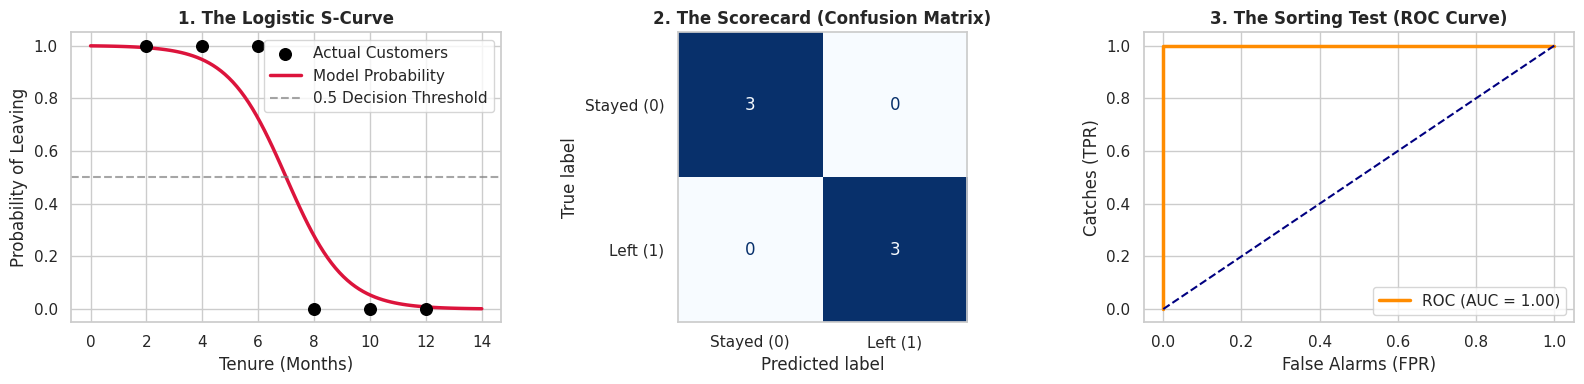

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

sns.set_theme(style="whitegrid")

# 1. Hardcoded toy dataset
X = np.array([[2], [4], [6], [8], [10], [12]])  # Tenure (Months)
y = np.array([1, 1, 1, 0, 0, 0])                 # 1 = Left, 0 = Stayed

# 2. Fit a bare-bones Logistic Regression model
clf = LogisticRegression()
clf.fit(X, y)

# 3. Predict on the exact same 6 points
y_pred = clf.predict(X)
y_probs = clf.predict_proba(X)[:, 1] # Probability of Churn (Class 1)

# --- VISUALIZATION BREAKDOWN ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Chart 1: The S-Curve (What Logistic Regression actually does)
X_test_curve = np.linspace(0, 14, 100).reshape(-1, 1)
probs_curve = clf.predict_proba(X_test_curve)[:, 1]

axes[0].scatter(X, y, color="black", s=70, zorder=3, label="Actual Customers")
axes[0].plot(X_test_curve, probs_curve, color="crimson", lw=2.5, label="Model Probability")
axes[0].axhline(0.5, color="grey", linestyle="--", alpha=0.7, label="0.5 Decision Threshold")
axes[0].set_title("1. The Logistic S-Curve", fontweight="bold")
axes[0].set_xlabel("Tenure (Months)")
axes[0].set_ylabel("Probability of Leaving")
axes[0].legend()

# Chart 2: The Confusion Matrix (Counting the bins)
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed (0)", "Left (1)"])
disp.plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("2. The Scorecard (Confusion Matrix)", fontweight="bold")
axes[1].grid(False)

# Chart 3: The ROC Curve (The Sliding Rule)
fpr, tpr, _ = roc_curve(y, y_probs)
axes[2].plot(fpr, tpr, color="darkorange", lw=2.5, label=f"ROC (AUC = {auc(fpr, tpr):.2f})")
axes[2].plot([0, 1], [0, 1], color="navy", linestyle="--")
axes[2].set_title("3. The Sorting Test (ROC Curve)", fontweight="bold")
axes[2].set_xlabel("False Alarms (FPR)")
axes[2].set_ylabel("Catches (TPR)")
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

### Visual Diagnostics Breakdown: What the Charts Actually Mean

#### 1. The Logistic S-Curve (The Decision Engine)
- **Why not a straight line?** If you draw a straight line through binary data (0 and 1), it shoots off toward positive and negative infinity. You end up with absurd predictions like "140% chance of leaving" or "-30% chance of staying."
- **The S-Bend (Sigmoid):** Logistic Regression bends that straight line into an S-curve, locking every possible prediction strictly between $0.0$ (0% chance) and $1.0$ (100% chance).
- **The Decision Cutoff:** Look at where the red curve crosses the horizontal $0.5$ line. It lands at **7 months**. If a customer has been around for less than 7 months, the model predicts they leave; if they cross the 7-month mark, the model bets they stay.

#### 2. The Scorecard (Confusion Matrix)
- It is simply a $2 \times 2$ sorting table that counts how well our predictions matched reality:
  - **Top-Left (True Negative):** Stayed, and we correctly said they stayed.
  - **Bottom-Right (True Positive):** Left, and we correctly caught them leaving.
  - **Off-Diagonals (The Mistakes):** The false alarms (False Positives) versus the customers who quietly slipped away unnoticed (False Negatives). In our toy example with a clean 7-month boundary, the model scores a perfect 6 out of 6.

#### 3. The Sorting Test (ROC Curve)
- **Beyond the 50% Guess:** What if we do not want to wait for a 50% probability before reaching out to a customer? What if we want to flag anyone with even a 20% risk?
- **The Threshold Sweep:** The ROC curve tests **every single possible cutoff between 0% and 100%**.
- **The Trade-Off:** It plots our **Catch Rate (Recall)** going up against our **False Alarm Rate** going right.
- **The Takeaway:** Because our toy model cleanly separated every churner from every stayer, the line shoots straight to the top-left corner, earning a perfect **1.0 AUC** (Area Under the Curve). It proves the model ranked every single person who left higher in risk than anyone who stayed.

# Appendix: The Complete Machine Learning Lifecycle (MLOps in the Real World)

### The Big Picture: Beyond the One-Way Street
In textbook exercises, machine learning looks like a straight line: grab data, fit a model, print an accuracy score, and turn it in.

In production, **machine learning is an infinite loop**. A static model deployed to the web begins to rot almost immediately as human habits evolve, competitor pricing shifts, and underlying patterns drift. Engineers use **MLOps (Machine Learning Operations)** to connect model training to continuous production monitoring, closing the loop so systems adapt instead of failing silently.

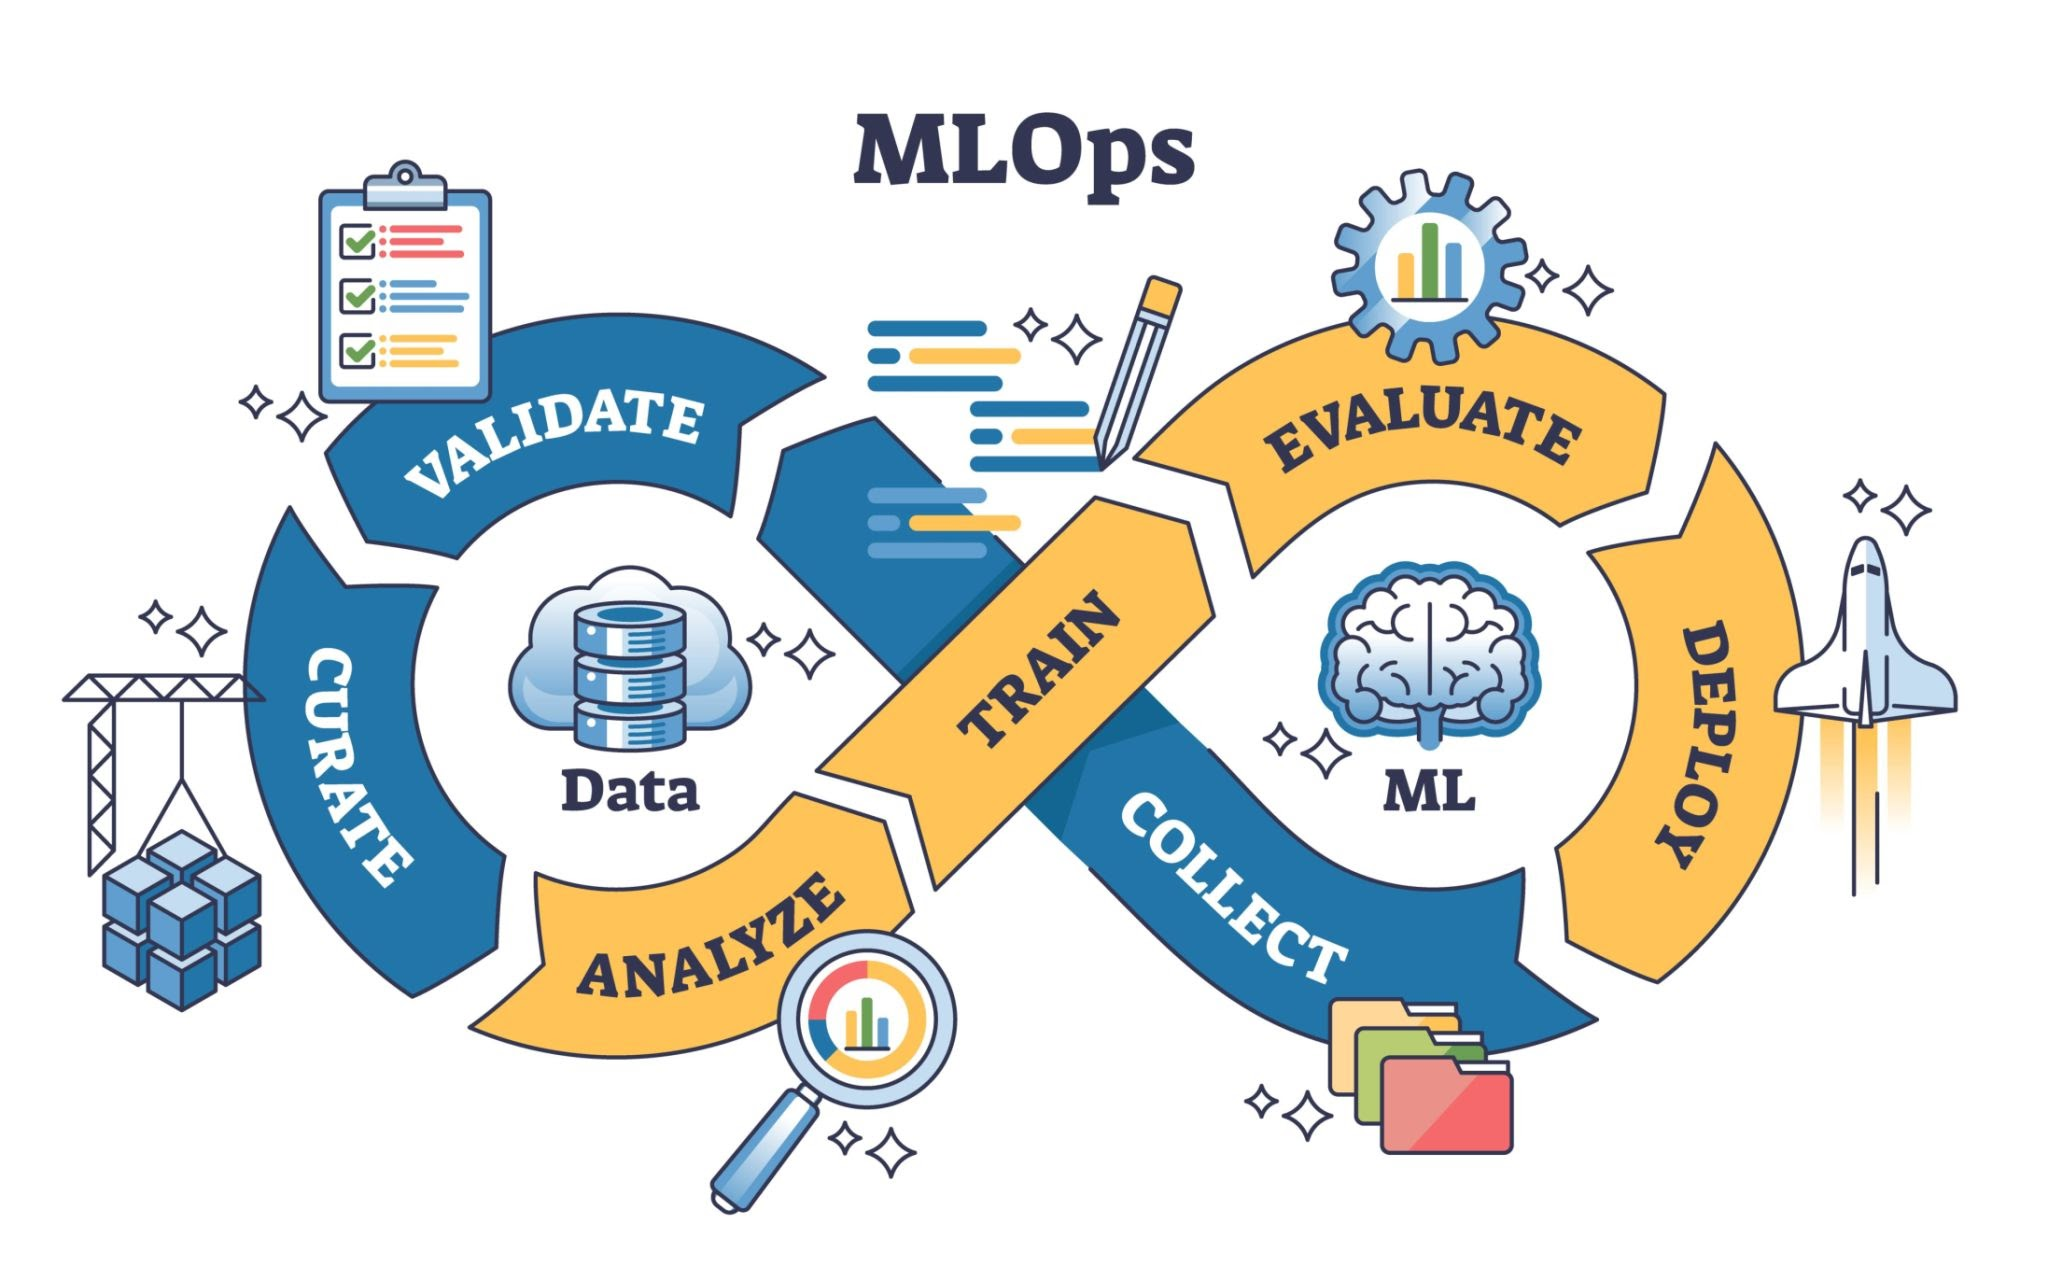

---

### The Real-World Cycle: The Commercial Bakery Metaphor

To understand how these continuous stages connect in practice, think of building an enterprise ML system like operating a **commercial bakery**:

1. **Sourcing the Ingredients (Data Ingestion & Cleaning):**
   You do not dump raw bags of uninspected flour straight into a commercial mixer. You sift out debris, check moisture levels, and discard spoiled batches. In our project, this was dropping useless identifier columns (`customerID`) and filling blank entries in `TotalCharges` with median values.
2. **Preparing the Dough (Feature Engineering & Standardization):**
   Flour, water, and yeast must be measured into precise, uniform ratios so every loaf bakes at the exact same rate. In our project, this was one-hot encoding categories into binary switches and using `StandardScaler` so multi-thousand-dollar total charges did not overwhelm small 1-to-24 month tenure counts.
3. **The Oven & The Taste Test (Model Training & Evaluation):**
   You bake batches using two distinct methods—a traditional single-pan approach (Logistic Regression) versus an artisanal rack oven with multiple trays (Random Forest). You do not judge quality on crust color alone; you run a blind taste test. In our project, this was checking the **Confusion Matrix** to ensure we were actually catching churning customers instead of relying on deceptive overall accuracy.
4. **Delivering to Store Shelves (Packaging & Deployment):**
   The winning recipe is boxed into standard packaging and distributed to store shelves so customers can buy it daily. In our pipeline, this was sealing the scaler and classifier into a single `.joblib` file and exposing it through a **FastAPI** web endpoint that outputs real-time risk scores in under 50 milliseconds.
5. **Customer Feedback & Recipe Revisions (Monitoring & Drift):**
   If customer tastes shift next season, or a supplier changes the flour blend, loaves start coming out dense. A good bakery catches the drop in sales immediately and tweaks the recipe rather than continuing to push out stale bread. In our system, this is **drift monitoring**—running weekly checks on incoming billing data and triggering automated retraining if predictive accuracy dips below our performance threshold.

---

### The Operational Takeaway
Whether in software engineering, instructional design, or machine learning, robust systems are never built as rigid, one-and-done linear checklists. They succeed by pairing a working prototype with clear health metrics and a structured revision loop.